In [2]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")  #Load Dataset
print(df.head()) # Display first rows
print(df.shape) # Display dataset size
print(df.columns) # Display column names

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [3]:
# Check missing values
print(df.isnull().sum())

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Check duplicates
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
0


In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 0. Reload dataset to ensure consistent state (optional, but good for self-contained cells)
df = pd.read_csv("StudentPerformanceFactors.csv")

# 0.1 Handle missing values comprehensively before encoding
# Fill numerical columns with their mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns with their mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 1. Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns before encoding:")
print(cat_cols)

# 2. Encode ordinal variables manually
# Motivation_Level has order: Low < Medium < High
if 'Motivation_Level' in df.columns:
    df['Motivation_Level'] = df['Motivation_Level'].map({
        'Low': 0,
        'Medium': 1,
        'High': 2
    })
# 3. Find remaining categorical columns (nominal variables)
nominal_cols = df.select_dtypes(include=['object']).columns

# 4. Apply One-Hot Encoding to nominal variables
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# 5. Convert True/False columns to 0/1
# Convert boolean columns
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)


# 6. Check result
print("\nData after encoding:")
print(df.head())

print("\nColumns after encoding:")
print(df.columns)

print("\nShape after encoding:")
print(df.shape)

Categorical columns before encoding:
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

Data after encoding:
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Motivation_Level  \
0             23          84            7               73                 0   
1             19          64            8               59                 0   
2             24          98            7               91                 1   
3             29          89            8               98                 1   
4             19          92            6               65                 1   

   Tutoring_Sessions  Physical_Activity  Exam_Score  Parental_Involvement_Low  \
0                  0                  3          67

In [5]:
from sklearn.model_selection import train_test_split

# Use ALL columns except target
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5285, 26)
X_test shape: (1322, 26)
y_train shape: (5285,)
y_test shape: (1322,)


In [6]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create copies for processing
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Identify categorical columns
categorical_cols = X_train_processed.select_dtypes(include=['object']).columns

# Apply Label Encoding to ALL categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    X_train_processed[col] = le.fit_transform(X_train_processed[col])
    X_test_processed[col] = le.transform(X_test_processed[col])

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nSample of scaled training data:")
print(X_train_scaled[:5])

print("\nSample of scaled test data:")
print(X_test_scaled[:5])


X_train_scaled shape: (5285, 26)
X_test_scaled shape: (1322, 26)

Sample of scaled training data:
[[ 1.1735788  -0.07584643  0.66909444 -0.83727669  1.58224197  0.40578449
   1.96490902  1.98359283 -1.0181399  -0.49852132 -1.00778813  0.81907391
   0.29077054  1.20943017 -0.82101014 -0.32928894  0.80687456  0.65952368
  -0.78877173 -0.82878319 -0.35144261 -1.00664459 -0.49585743  1.51150549
  -1.21037955 -1.16999695]
 [-0.66198319  0.53189424 -0.01674034  1.31472787  0.1414858   0.40578449
   0.03038142 -0.50413572 -1.0181399  -0.49852132  0.99227205  0.81907391
   0.29077054  1.20943017 -0.82101014 -0.32928894 -1.23935002  0.65952368
   1.26779392 -0.82878319 -0.35144261  0.99339927 -0.49585743  1.51150549
  -1.21037955 -1.16999695]
 [ 0.33923244  0.61871433  0.66909444  0.55111335 -1.29927037 -0.40501741
  -1.90414618  1.98359283 -1.0181399  -0.49852132  0.99227205 -1.22089104
   0.29077054  1.20943017 -0.82101014 -0.32928894  0.80687456  0.65952368
   1.26779392 -0.82878319 -0.35144

In [7]:
import pandas as pd

df_full = pd.read_csv("StudentPerformanceFactors.csv")

print(df_full.head())

df = df_full[['Hours_Studied', 'Attendance', 'Sleep_Hours',
              'Previous_Scores', 'Tutoring_Sessions',
              'Motivation_Level', 'Exam_Score']]

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [8]:
import pandas as pd

df_full = pd.read_csv("StudentPerformanceFactors.csv")

print("Missing values before:")
print(df_full.isnull().sum())

# Fill numeric
df_full.fillna(df_full.mean(numeric_only=True), inplace=True)

# Fill categorical (fixed)
for col in df_full.select_dtypes(include=['object']).columns:
    df_full[col] = df_full[col].fillna(df_full[col].mode()[0])

print("\nMissing values after:")
print(df_full.isnull().sum())

Missing values before:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Missing values after:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access          

In [9]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

print(X.head())
print(y.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [10]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

# Select ALL numerical independent variables
numerical_columns = df.drop('Exam_Score', axis=1)\
                      .select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("\nColumn:", col)
    print("Number of outliers:", outliers.shape[0])


Column: Hours_Studied
Number of outliers: 43

Column: Attendance
Number of outliers: 0

Column: Sleep_Hours
Number of outliers: 0

Column: Previous_Scores
Number of outliers: 0

Column: Tutoring_Sessions
Number of outliers: 430

Column: Physical_Activity
Number of outliers: 0


In [11]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

print("Dataset shape before removing outliers:", df.shape)

# Select numerical independent variables
numerical_columns = df.drop('Exam_Score', axis=1)\
                      .select_dtypes(include=['int64', 'float64']).columns

# Combine outliers into one DataFrame
all_outliers = pd.DataFrame()

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    all_outliers = pd.concat([all_outliers, outliers])

# Remove duplicate rows
all_outliers = all_outliers.drop_duplicates()

print("Total combined outliers:", all_outliers.shape)

Dataset shape before removing outliers: (6607, 20)
Total combined outliers: (473, 20)


In [12]:
numerical_columns = df.drop('Exam_Score', axis=1)\
                      .select_dtypes(include=['int64', 'float64']).columns
all_outliers = pd.DataFrame()

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    all_outliers = pd.concat([all_outliers, outliers])

# remove duplicates
all_outliers = all_outliers.drop_duplicates()

# remove outlier rows from dataset
df = df.drop(all_outliers.index)

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (6134, 20)


In [13]:
import pandas as pd

df_full = pd.read_csv("StudentPerformanceFactors.csv")

X = df_full.drop('Exam_Score', axis=1)

pd.set_option('display.max_columns', None)

print(X.head())
print(X.shape)

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [14]:
y = df_full['Exam_Score']

print(y.head())
print(y.shape)

0    67
1    61
2    74
3    71
4    70
Name: Exam_Score, dtype: int64
(6607,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5285, 19)
X_test shape: (1322, 19)
y_train shape: (5285,)
y_test shape: (1322,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Load dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Use ALL columns except target
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Encode ALL categorical columns
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression predictions:")
print(y_pred_lr[:5])

Linear Regression predictions:
[65.20083182 67.44490122 69.78414258 67.2956279  66.74660215]


In [16]:
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Reload the dataset to ensure we work with the original data before any global modifications
df_current = pd.read_csv("StudentPerformanceFactors.csv")

# Fill missing values for numerical columns (mean) and categorical (mode) if any
df_current.fillna(df_current.mean(numeric_only=True), inplace=True)
for col in df_current.select_dtypes(include=['object']).columns:
    df_current[col] = df_current[col].fillna(df_current[col].mode()[0])

# Define features (X) and target (y) from the processed df_current
X_poly_full = df_current.drop('Exam_Score', axis=1)
y_poly = df_current['Exam_Score']

# Split FIRST
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly_full, y_poly, test_size=0.2, random_state=42
)

# Encode ALL categorical columns in X_train_p and X_test_p
for col in X_train_p.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train_p[col] = le.fit_transform(X_train_p[col])
    X_test_p[col] = le.transform(X_test_p[col])

# Apply PolynomialFeatures AFTER encoding and split
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_p)
X_test_poly = poly.transform(X_test_p)

# Train Polynomial Regression
pr = LinearRegression()
pr.fit(X_train_poly, y_train_p)

y_pred_pr = pr.predict(X_test_poly)

print("Polynomial Regression predictions:")
print(y_pred_pr[:5])


Polynomial Regression predictions:
[64.54462805 64.98657545 71.20596963 64.03756947 66.43992714]


In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression predictions:")
print(y_pred_ridge[:5])

Ridge Regression predictions:
[64.50932663 65.2542554  71.50914394 64.26597532 66.53582917]


In [19]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Regression predictions:")
print(y_pred_lasso[:5])

Lasso Regression predictions:
[66.23534324 66.4765894  68.57325074 67.48764303 65.46905255]


In [20]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet()
enet.fit(X_train_scaled, y_train)

y_pred_enet = enet.predict(X_test_scaled)

print("Elastic Net predictions:")
print(y_pred_enet[:5])

Elastic Net predictions:
[66.32297965 66.7508509  68.29609478 67.18008106 65.83185769]


In [25]:
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

# handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# features and target
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# encode categorical columns
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# polynomial AFTER split
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Train shape:", X_train_poly.shape)
print("Test shape:", X_test_poly.shape)

Train shape: (5285, 210)
Test shape: (1322, 210)


In [28]:
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Polynomial Regression
mse_pr = mean_squared_error(y_test_p, y_pred_pr)
r2_pr = r2_score(y_test_p, y_pred_pr)

# Ridge Regression
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso Regression
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Elastic Net
mse_elastic = mean_squared_error(y_test, y_pred_enet)
r2_elastic = r2_score(y_test, y_pred_enet)

print("Linear Regression -> MSE:", mse_lr, "R2:", r2_lr)
print("Polynomial Regression -> MSE:", mse_pr, "R2:", r2_pr)
print("Ridge Regression -> MSE:", mse_ridge, "R2:", r2_ridge)
print("Lasso Regression -> MSE:", mse_lasso, "R2:", r2_lasso)
print("Elastic Net -> MSE:", mse_elastic, "R2:", r2_elastic)

Linear Regression -> MSE: 3.2551020435554743 R2: 0.769714513331266
Polynomial Regression -> MSE: 3.418582473341836 R2: 0.7581489249624771
Ridge Regression -> MSE: 3.255032685678928 R2: 0.7697194201243991
Lasso Regression -> MSE: 7.946270181394097 R2: 0.4378330782144024
Elastic Net -> MSE: 7.6710212662937245 R2: 0.4573058411326719


In [32]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear', 'Polynomial', 'Ridge', 'Lasso', 'Elastic Net'],
    'MSE': [mse_lr, mse_pr, mse_ridge, mse_lasso, mse_elastic],
    'R2': [r2_lr, r2_pr, r2_ridge, r2_lasso, r2_elastic]
})

print(results)

         Model       MSE        R2
0       Linear  3.255102  0.769715
1   Polynomial  3.418582  0.758149
2        Ridge  3.255033  0.769719
3        Lasso  7.946270  0.437833
4  Elastic Net  7.671021  0.457306


In [33]:
best_model = results.loc[results['R2'].idxmax()]

print("\nBest Model is:", best_model['Model'])
print("R2 Score:", best_model['R2'])
print("MSE:", best_model['MSE'])


Best Model is: Ridge
R2 Score: 0.7697194201243991
MSE: 3.255032685678928


In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

y_train = y_train_p

pr.fit(X_train_poly, y_train)

y_pred_pr = pr.predict(X_test_poly)

print("\nPolynomial Regression Equation:")
print("Intercept:", pr.intercept_)
print("Number of coefficients:", len(pr.coef_))
print("Coefficients:", pr.coef_)


Polynomial Regression Equation:
Intercept: 46.874687353171865
Number of coefficients: 210
Coefficients: [-1.41473891e-13  1.79266578e-01  2.05020360e-01 -3.42557009e+00
 -3.77344540e+00  8.03952155e-01 -1.44895690e-01 -3.59025330e-02
 -2.02202458e+00  2.53141445e-01  5.72018517e-01 -1.52532785e+00
 -1.63097485e+00  2.73105534e-01  1.35095291e-01 -3.32371947e-01
  1.32426986e+00 -1.90923377e+00 -1.25288428e-01  7.01205085e-01
  6.35318998e-04  5.68820520e-04  2.00671368e-03  8.90311634e-03
 -9.58492439e-03  2.86598585e-03 -6.04992640e-05  3.65421903e-03
 -2.26103711e-02  1.00737609e-03 -1.10454206e-02 -2.81280775e-03
  3.27539664e-02  1.11710864e-02  7.90027245e-03 -1.71518709e-02
  3.72098847e-03 -6.12885949e-03 -1.84000525e-03 -1.60324637e-04
  4.19463982e-04 -3.59484712e-03 -1.44133796e-03 -7.52222311e-04
  3.61753817e-04 -1.12780428e-03  1.09590806e-03  1.76818614e-03
 -1.26955061e-04 -2.63889024e-03  7.45173880e-04 -1.98089309e-03
  5.61716985e-04 -1.74365394e-02 -2.41321484e-03  

In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\nLinear Regression Equation:")
print("Intercept:", lr.intercept_)
print("Number of coefficients:", len(lr.coef_))
print("Coefficients:", lr.coef_)


Linear Regression Equation:
Intercept: 67.2151371807001
Number of coefficients: 26
Coefficients: [ 1.75657997  2.29026151 -0.01815982  0.70635941  0.36000983  0.62631453
  0.1991981  -0.80457924 -0.5343398  -0.83856853 -0.51563601  0.28602359
  0.25708041 -0.54426514 -0.31377979 -0.30237299 -0.27230852  0.00787034
  0.27509629  0.51660536 -0.26774702 -0.22962959  0.20456335  0.14596641
  0.41913905 -0.01275821]


In [37]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("\nRidge Regression Equation:")
print("Intercept:", ridge.intercept_)
print("Number of coefficients:", len(ridge.coef_))
print("Coefficients:", ridge.coef_)


Ridge Regression Equation:
Intercept: 67.2151371807001
Number of coefficients: 26
Coefficients: [ 1.75623495  2.28982549 -0.01817364  0.70621478  0.35992461  0.62619445
  0.199139   -0.80428186 -0.53409559 -0.83827407 -0.51539134  0.28596977
  0.25701724 -0.54399355 -0.31353745 -0.30226802 -0.27222202  0.00785093
  0.27489805  0.51637453 -0.26771349 -0.22957759  0.20456642  0.14573676
  0.41887312 -0.01275449]


In [38]:
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)


print("\nLasso Regression Equation:")
print("Intercept:", lasso.intercept_)
print("Number of coefficients:", len(lasso.coef_))
print("Coefficients:", lasso.coef_)


Lasso Regression Equation:
Intercept: 67.2151371807001
Number of coefficients: 26
Coefficients: [ 0.72285975  1.27694194 -0.          0.          0.          0.
  0.         -0.         -0.         -0.         -0.          0.
  0.         -0.          0.         -0.         -0.         -0.
 -0.          0.         -0.         -0.          0.         -0.
  0.          0.        ]


In [39]:
enet = ElasticNet()
enet.fit(X_train_scaled, y_train)

y_pred_enet = enet.predict(X_test_scaled)


print("\nElastic Net Regression Equation:")
print("Intercept:", enet.intercept_)
print("Number of coefficients:", len(enet.coef_))
print("Coefficients:", enet.coef_)


Elastic Net Regression Equation:
Intercept: 67.2151371807001
Number of coefficients: 26
Coefficients: [ 0.814932    1.18557966 -0.          0.12173105  0.          0.07762862
  0.         -0.         -0.         -0.02627421 -0.          0.
  0.         -0.          0.         -0.         -0.         -0.
 -0.          0.         -0.         -0.          0.         -0.
  0.          0.        ]


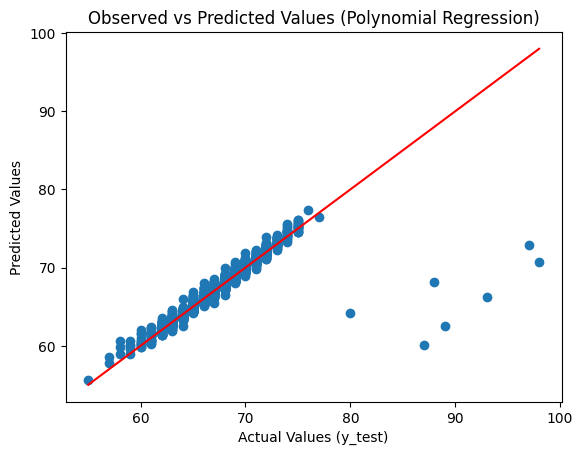

In [40]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(y_test, y_pred_pr)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted Values (Polynomial Regression)")

plt.show()

In [41]:
# Create categorical target
df['Performance_Level'] = pd.cut(
    df['Exam_Score'],
    bins=[0, 60, 75, 105],
    labels=['Low', 'Medium', 'High']
)

# Show output
print(df['Performance_Level'].value_counts())

Performance_Level
Medium    6386
Low        145
High        76
Name: count, dtype: int64


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

df['Performance_Level'] = pd.cut(
    df['Exam_Score'],
    bins=[0, 60, 75, 105],
    labels=['Low', 'Medium', 'High']
)
X = df.drop(['Exam_Score', 'Performance_Level'], axis=1)
y = df['Performance_Level']

print("Target distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight='balanced'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM": SVC(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB()
}
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
    errors = (y_test != y_pred).sum()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append([name, cm, errors, accuracy, precision, recall, f1])
results_df = pd.DataFrame(results, columns=[
    'Model', 'Confusion Matrix', 'Errors', 'Accuracy',
    'Precision', 'Recall', 'F1-Score'
])

print(results_df)

best_classifier = results_df.loc[results_df['F1-Score'].idxmax()]

print("\nBest Classifier:")
print(best_classifier)

Target distribution:
Performance_Level
Medium    6386
Low        145
High        76
Name: count, dtype: int64
                 Model                         Confusion Matrix  Errors  \
0  Logistic Regression  [[18, 5, 1], [67, 849, 373], [2, 4, 3]]     452   
1  K-Nearest Neighbors    [[4, 20, 0], [3, 1286, 0], [0, 9, 0]]      32   
2                  SVM  [[19, 5, 0], [18, 1258, 13], [2, 7, 0]]      45   
3        Decision Tree   [[7, 16, 1], [9, 1263, 17], [0, 9, 0]]      52   
4        Random Forest    [[1, 23, 0], [0, 1289, 0], [0, 9, 0]]      32   
5          Naive Bayes    [[8, 16, 0], [7, 1280, 2], [0, 9, 0]]      34   

   Accuracy  Precision    Recall  F1-Score  
0  0.658094   0.968620  0.658094  0.777123  
1  0.975794   0.963909  0.975794  0.967741  
2  0.965961   0.974669  0.965961  0.969604  
3  0.960666   0.964055  0.960666  0.962095  
4  0.975794   0.969573  0.975794  0.964536  
5  0.974281   0.966041  0.974281  0.969706  

Best Classifier:
Model                          

In [43]:
best_model_name = best_classifier['Model']
best_model = models[best_model_name]

best_model.fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_test_scaled)

predicted_counts = pd.Series(y_pred_best).value_counts().reindex(
    ['Low', 'Medium', 'High'], fill_value=0
)

print("Best Classifier:", best_model_name)
print(predicted_counts)

Best Classifier: Naive Bayes
Low         15
Medium    1305
High         2
Name: count, dtype: int64


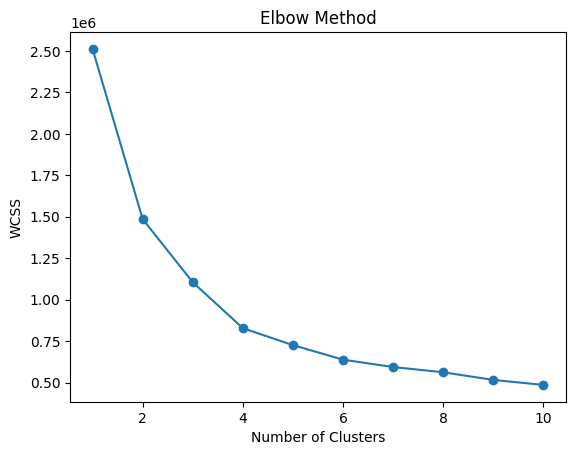

Cluster
1    2787
2    1910
0    1910
Name: count, dtype: int64


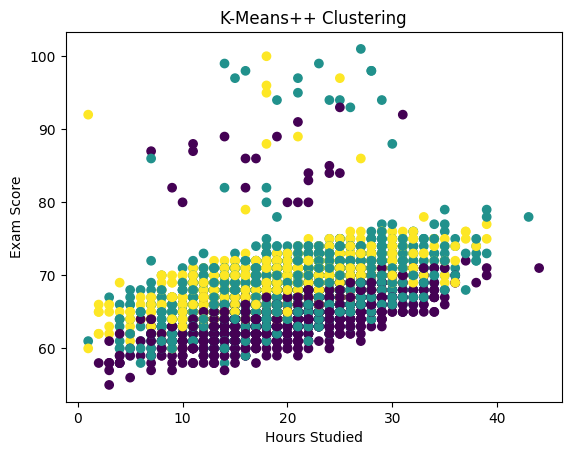

In [45]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select features
X_cluster = df[['Hours_Studied', 'Attendance', 'Sleep_Hours',
                'Previous_Scores', 'Tutoring_Sessions']]

# 2. Elbow Method using K-Means++
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# 3. Apply K-Means++ with 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

print(df['Cluster'].value_counts())

# 4. Visualization
plt.scatter(df['Hours_Studied'], df['Exam_Score'], c=df['Cluster'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('K-Means++ Clustering')
plt.show()